In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import random

%matplotlib widget

The bread will take 1.42 seconds to go from the table to the floor.
The time the bread spent on the table was 0.64 seconds and the free fall time was 0.78 seconds
5-second rule still applies
Input toast for Toast Falling	 Input stats for motion statistics


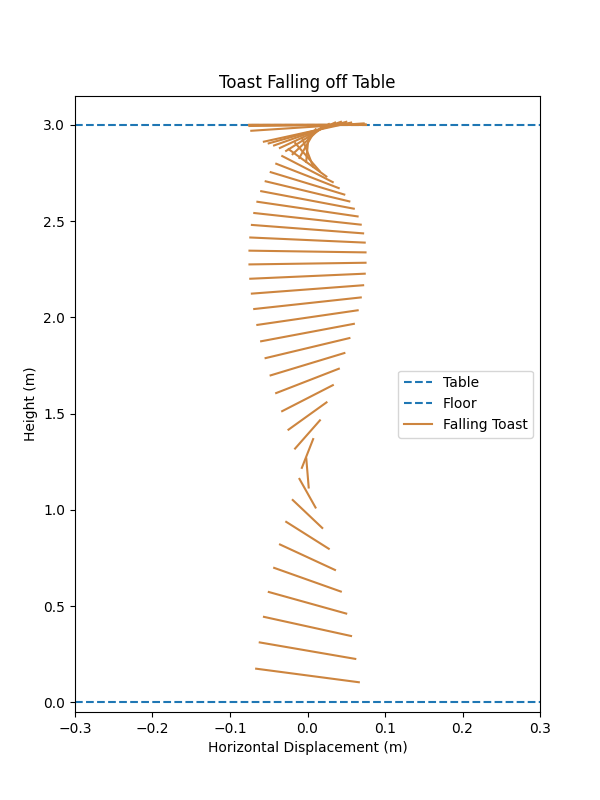

In [5]:
# Physical parameters of system

g = 9.81                # m/s/s
m = 0.045               # kg
L = 0.15                # Length of toast
h = 3                   # Height of the table
I = (1/12)*m*(L**2)     # Moment of inertia (thin uniform square slab)

# Initial conditions

theta0 = 0              # RADIANS! NOT DEGREES!
w0 = 0                  # rad/sec, also known as theta dot
r0 = 1e-5               # m, inital position for the bread, I dont think this can be zero since this is the basis for most of the ODEs
rdot_0 = 0              # m/s, this is the radius velocity

# The actual meat and potatoes

"""
Prior to solving the ode, its important to know that the condition for the toast leaves the table
when gcos(theta) = 2(rdot)(thetadot).

This means we need to kinda patch this together for graphs, one for some visualizations. This would be where
there is a list for prior to the table fall and then after. So one for the length prior to gcos(theta) = 2(rdot)(thetadot)
and then one after equal to free fall (t=sqrt(2h/g))
"""

def euler_lagrange(x,t):
    theta, omega, r, rad_vel = x[0], x[1], x[2], x[3]

    theta_dot = omega
    r_dot = rad_vel

    rad_accel = r * theta_dot**2 + g *np.sin(theta)
    anguler_accel = (r*(g*np.cos(theta)- 2 *rad_vel*theta_dot))/(r**2 + I/m)

    return theta_dot, anguler_accel, rad_vel, rad_accel

initial_conditions = [theta0,w0,r0,rdot_0]

# This is only realistsic if the middle arguement is <= 10
# Im not really sure why but its probably something to do with the euler lagrange equations used
tpoints = np.linspace(0,5,10000)

xpoints = odeint(euler_lagrange, initial_conditions, tpoints)

theta_points = xpoints[:,0]
omega_points = xpoints[:,1]
r_points = xpoints[:,2]
rad_vel_points = xpoints[:,3]

# Time Stuff!!

max_omega = max(omega_points)       # This tracks max angular velocity
max_idx = np.argmax(omega_points)
t_leave = tpoints[max_idx]

t_final = t_leave + np.sqrt((2*h)/g)

# Second ODE

def theta_ode(x,t):
    theta, omega = x
    theta_dot = omega
    omega_dot = 0

    return theta_dot, omega_dot

theta_ode_init = [theta_points[max_idx],max_omega]

# At this point, some of the vars might be interestingly named
# So from here, im only interested in the data that has the _final prefix

t_freefall = np.linspace(t_leave,t_final, 10000)
theta_ode_points = odeint(theta_ode,theta_ode_init, t_freefall)
theta_points_freefall = theta_ode_points[:,0]
omega_points_final = theta_ode_points[:,1]

theta_final = np.concatenate((theta_points[:max_idx+1],theta_points_freefall))
time_final = np.concatenate((tpoints[:max_idx+1], t_freefall))
omega_final = np.concatenate((omega_points[:max_idx+1], omega_points_final)) 

r_points_table = r_points[:max_idx+1]
rad_vel_points_table = rad_vel_points[:max_idx+1]

r_points_freefall= []

# This approximation works way better when we assume initially a non-zero
# velocity as the toast leaves the table

for t in t_freefall:
    rf = r_points_table[-1] + 0.5*g*((t-t_leave)**2)
    r_points_freefall.append(rf)

r_final = np.concatenate((r_points_table,r_points_freefall))

# Because of this approximation, we gotta trim some vals off of everything

for i,line in enumerate(r_final):
    if r_final[i] >= h:
        idx_trim = i
        break

time_final = time_final[:idx_trim+1]
theta_final = theta_final[:idx_trim+1]
omega_final = omega_final[:idx_trim+1]
r_final = r_final[:idx_trim+1]

# Summary

print(f'The bread will take {time_final[-1]:.2f} seconds to go from the table to the floor.')
print(f'The time the bread spent on the table was {t_leave:.2f} seconds and the free fall time was {time_final[-1]-t_leave:.2f} seconds')

final_angle = theta_final[-1] % (2*np.pi)

idx_rand = random.randint(0,4)
if np.pi/2 < final_angle <3*np.pi/2:
    butter_side_down = ["Thus, the world is not fair as our toast has fallen butter side down", "You better put more toast in the toaster, and maybe get a mop",
                        'What feels like misfortune is often just inevitability in motion', 'In the end, the toast obeys the world, not our expectations.',
                        'The toast didn’t choose the buttered side — it simply followed its path.']

    print(butter_side_down[idx_rand])
else:
    butter_side_up = ['5-second rule still applies', 'Youll need cereal with that toast', 'Not every fall ends in disappointment','Even simple events can restore a little optimism',
                      'For once, expectation and reality agree.']
    print(butter_side_up[idx_rand])

# This is a query made for myself to easily display graphs for my purposes
# If creating function, feel free omit everything past this comment

print("Input toast for Toast Falling\t Input stats for motion statistics")
graph_input = input()

if graph_input == "toast" or graph_input == 'bread':

    # Toast falling through time; plot

    plt.figure(figsize=(6,8))
    plt.grid(False)
    plt.axhline(h, label='Table', linestyle='--')
    plt.axhline(0, label = 'Floor', linestyle='--')
    plt.ylim(-0.05, 0.15+h)
    plt.xlim(-0.3,0.3)
    plt.title('Toast Falling off Table')
    plt.ylabel('Height (m)')
    plt.xlabel('Horizontal Displacement (m)')

    snapshots = 50                      # changes number of snapshots of the toast falling on plot, found that 50 is the most descript
    step = len(time_final)//snapshots   # Floor division, needed because step needs to be integer

    for i in range(0, len(time_final), step):
        theta = theta_final[i]
        x_center = 0                # Only the horizontal component really changes as the toast falls since no assumed initial horizontal velocity
        y_center = h - r_final[i]

        x1 = x_center - 0.5*L*np.cos(theta)
        y1 = y_center - 0.5*L*np.sin(theta)
        x2 = x_center + 0.5*L*np.cos(theta)
        y2 = y_center + 0.5*L*np.sin(theta)

        if y1 < 0 or y2 < 0:            # Funny visiual glitch, I dont want the final bread to go through the floor
            continue


        plt.plot([x1, x2], [y1, y2], color='peru')

    plt.plot([], [], color='peru', label='Falling Toast')       # This is just here for the legend
    plt.legend(loc='best')
    plt.show()

    # This might look really funny if you set the table height to a really high number

elif graph_input == "stats":
    plt.figure(figsize=(10,10))
    
    # Subplot 1
    plt.subplot(311)
    plt.title('Positional Statistics as the Toast Falls')

    plt.ylabel('Center-of-Mass Position (m)')
    plt.plot(time_final, r_final)

    # Subplot 2
    plt.subplot(312)
    plt.ylabel('Angle (Degrees)')
    plt.plot(time_final, theta_final* 180/np.pi)

    #Subplot 3
    plt.subplot(313)
    plt.ylabel('Angular Velocity (rad/sec)')
    plt.xlabel('Time (s)')

    plt.plot(time_final, omega_final)

    plt.tight_layout()
    plt.show()

else:
    raise Exception("Invalid Input, rerun code.")

In [2]:
# Make it a function with respect to the length of the table

def toast(Height = 0.75, gravity = 9.81, mass = 0.045, Length = 0.1):

    # Physical parameters of system

    g = gravity             # m/s/s
    m = mass                # kg
    L = Length              # Length of toast
    h = Height              # Height of the table
    I = (1/12)*m*(L**2)     # Moment of inertia (thin uniform square slab)

    # Initial conditions

    theta0 = 0              # RADIANS! NOT DEGREES!
    w0 = 0                  # rad/sec, also known as theta dot
    r0 = 1e-5               # m, inital position for the bread, I dont think this can be zero since this is the basis for most of the ODEs
    rdot_0 = 0              # m/s, this is the radius velocity

    # The actual meat and potatoes

    """
    Prior to solving the ode, its important to know that the condition for the toast leaves the table
    when gcos(theta) = 2(rdot)(thetadot).

    This means we need to kinda patch this together for graphs, one for some visualizations. This would be where
    there is a list for prior to the table fall and then after. So one for the length prior to gcos(theta) = 2(rdot)(thetadot)
    and then one after equal to free fall (t=sqrt(2h/g))
    """

    def euler_lagrange(x,t):
        theta, omega, r, rad_vel = x[0], x[1], x[2], x[3]

        theta_dot = omega
        r_dot = rad_vel

        rad_accel = r * theta_dot**2 + g *np.sin(theta)
        anguler_accel = (r*(g*np.cos(theta)- 2 *rad_vel*theta_dot))/(r**2 + I/m)

        return theta_dot, anguler_accel, rad_vel, rad_accel

    initial_conditions = [theta0,w0,r0,rdot_0]

    # This is only realistsic if the middle arguement is <= 10
    # Im not really sure why but its probably something to do with the euler lagrange equations used
    tpoints = np.linspace(0,5,10000)

    xpoints = odeint(euler_lagrange, initial_conditions, tpoints)

    theta_points = xpoints[:,0]
    omega_points = xpoints[:,1]
    r_points = xpoints[:,2]
    rad_vel_points = xpoints[:,3]

    # Time Stuff!!

    max_omega = max(omega_points)
    max_idx = np.argmax(omega_points)
    t_leave = tpoints[max_idx]

    t_final = t_leave + np.sqrt((2*h)/g)

    # Second ODE

    def theta_ode(x,t):
        theta, omega = x
        theta_dot = omega
        omega_dot = 0

        return theta_dot, omega_dot

    theta_ode_init = [theta_points[max_idx],max_omega]

    # At this point, some of the vars might be interestingly named
    # So from here, im only interested in the data that has the _final prefix

    t_freefall = np.linspace(t_leave,t_final, 10000)
    theta_ode_points = odeint(theta_ode,theta_ode_init, t_freefall)
    theta_points_freefall = theta_ode_points[:,0]
    omega_points_final = theta_ode_points[:,1]

    theta_final = np.concatenate((theta_points[:max_idx+1],theta_points_freefall))
    time_final = np.concatenate((tpoints[:max_idx+1], t_freefall))
    omega_final = np.concatenate((omega_points[:max_idx+1], omega_points_final)) 

    r_points_table = r_points[:max_idx+1]
    rad_vel_points_table = rad_vel_points[:max_idx+1]

    r_points_freefall= []

    # This approximation works way better when we assume initially a non-zero
    # velocity as the toast leaves the table

    for t in t_freefall:
        rf = r_points_table[-1] + 0.5*g*((t-t_leave)**2)
        r_points_freefall.append(rf)

    r_final = np.concatenate((r_points_table,r_points_freefall))

    # Because of this approximation, we gotta trim some vals off of everything

    for i,line in enumerate(r_final):
        if r_final[i] >= h:
            idx_trim = i
            break

    time_final = time_final[:idx_trim+1]
    theta_final = theta_final[:idx_trim+1]
    omega_final = omega_final[:idx_trim+1]
    r_final = r_final[:idx_trim+1]

    # Summary

    final_angle = theta_final[-1] % (2*np.pi)



    idx_rand = random.randint(0,4)
    if np.pi/2 < final_angle <3*np.pi/2:
    #    butter_side_down = ["Thus, the world is not fair as our toast has fallen butter side down", "You better put more toast in the toaster, and maybe get a mop",
    #                        'What feels like misfortune is often just inevitability in motion', 'In the end, the toast obeys the world, not our expectations.',
    #                        'The toast didn’t choose the buttered side — it simply followed its path.']
    #
    #    print(butter_side_down[idx_rand])
        return True, final_angle
    else:
    #    butter_side_up = ['5-second rule still applies', 'Youll need cereal with that toast', 'Not every fall ends in disappointment','Even simple events can restore a little optimism',
    #                    'For once, expectation and reality agree.']
    #   print(butter_side_up[idx_rand])
        return False, final_angle

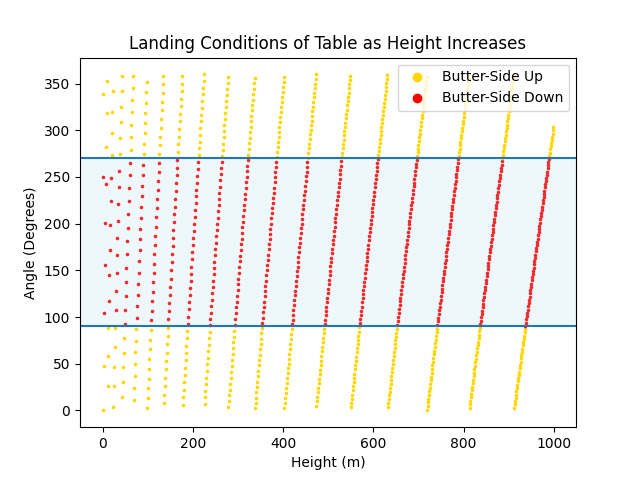

In [3]:
"""
Plot for Length vs Landing Angle
for the infinite case

Really interesting cyclical relationship
"""

lengths = np.arange(0,1000,1)          # Main parameters
landing_angle = []
butter_side = []

for L in lengths:
    a, b = toast(L)
    landing_angle.append(b)
    butter_side.append(a)

plt.figure()

oscillation = []

for i in range(len(lengths)):
    if butter_side[i] == True:
        plt.scatter(lengths[i],landing_angle[i]*180/np.pi, color='Red',s=2.5)
    else:   
        oscillation.append(lengths[i])
        plt.scatter(lengths[i],landing_angle[i]*180/np.pi, color='Gold', s=2.5)

plt.scatter([],[], color='gold',label='Butter-Side Up')
plt.scatter([],[],color='red',label='Butter-Side Down')
plt.axhline(90)
plt.axhline(270)
plt.axhspan(90,270,color='lightblue', alpha=0.2)
plt.title('Landing Conditions of Table as Height Increases')
plt.xlabel('Height (m)')
plt.ylabel('Angle (Degrees)')
plt.legend()
plt.show()

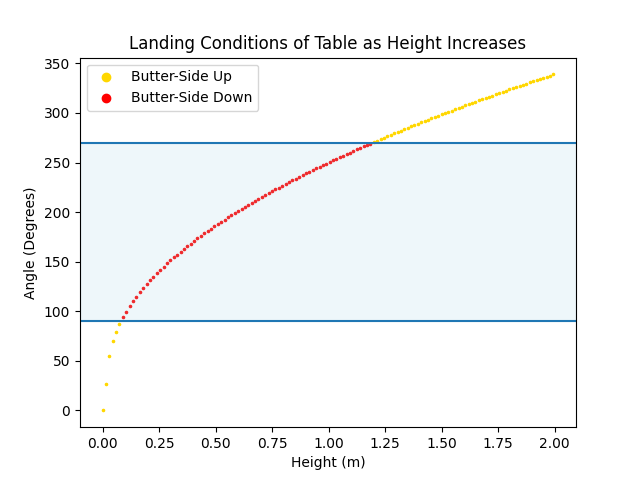

In [10]:
"""
Plot for Length vs Landing Angle
for the 0 case

Really interesting cyclical relationship
"""

lengths = np.arange(0,2,0.015)          # Main parameters
landing_angle = []
butter_side = []

for L in lengths:
    a, b = toast(L)
    landing_angle.append(b)
    butter_side.append(a)

plt.figure()

for i in range(len(lengths)):
    if butter_side[i] == True:
        plt.scatter(lengths[i],landing_angle[i]*180/np.pi, color='Red',s=2.5)
    else:   
        plt.scatter(lengths[i],landing_angle[i]*180/np.pi, color='Gold', s=2.5)

plt.scatter([],[], color='gold',label='Butter-Side Up')
plt.scatter([],[],color='red',label='Butter-Side Down')
plt.axhline(90)
plt.axhline(270)
plt.axhspan(90,270,color='lightblue', alpha=0.2)
plt.title('Landing Conditions of Table as Height Increases')
plt.xlabel('Height (m)')
plt.ylabel('Angle (Degrees)')
plt.legend()
plt.show()